
# Free Throw Success Classification (Beginner-Friendly)

This project uses the `combined.csv` dataset (NBA per-game player-season stats from Basketball-Reference) to build **a classification model**.

## Important: What is the target here?
This dataset is **not shot-by-shot free throw attempts** (it does not have a `made/missed` outcome per free throw). Instead it has season-level *rates* like `FT%`.

So we define a clean binary target:

- `target = 1` if a player's **season FT%** is **greater than or equal to the league average FT%** for that same season.
- `target = 0` otherwise.

This gives us a meaningful and well-defined classification task: **is this player an above-average free throw shooter (for that season)?**

We also take care to avoid leakage:
- We **drop `FT%` from the features** (because it's used to build the target).
- We avoid directly using anything that is a trivial re-expression of `FT%`.


## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = 'combined.csv'
df_raw = pd.read_csv(DATA_PATH)

print('Shape:', df_raw.shape)
df_raw.head()

Shape: (26292, 32)


,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,PTS,Awards,Season,3P,3PA,3P%,2P,2PA,2P%,eFG%
0,1.0,Bob McAdoo,23.0,BUF,C,82.0,NaN,43.2,13.4,26.1,...,34.5,"MVP-1,AS,NBA1",1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,Rick Barry,30.0,GSW,SF,80.0,NaN,40.4,12.9,27.7,...,30.6,"MVP-4,AS,NBA1",1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,Kareem Abdul-Jabbar,27.0,MIL,C,65.0,NaN,42.3,12.5,24.4,...,30.0,"MVP-5,AS,DEF1",1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,Tiny Archibald,26.0,KCO,PG,82.0,NaN,39.6,9.3,20.3,...,26.5,"MVP-6,AS,NBA1",1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,Charlie Scott,26.0,PHO,PG,69.0,NaN,37.6,10.2,23.1,...,24.3,AS,1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Basic Structure

In [2]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26292 entries, 0 to 26291
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      26241 non-null  float64
 1   Player  26292 non-null  object 
 2   Age     26241 non-null  float64
 3   Team    26241 non-null  object 
 4   Pos     26241 non-null  object 
 5   G       26241 non-null  float64
 6   GS      24404 non-null  float64
 7   MP      26241 non-null  float64
 8   FG      26241 non-null  float64
 9   FGA     26241 non-null  float64
 10  FG%     26155 non-null  float64
 11  FT      26241 non-null  float64
 12  FTA     26241 non-null  float64
 13  FT%     25109 non-null  float64
 14  ORB     26241 non-null  float64
 15  DRB     26241 non-null  float64
 16  TRB     26241 non-null  float64
 17  AST     26241 non-null  float64
 18  STL     26241 non-null  float64
 19  BLK     26241 non-null  float64
 20  TOV     25348 non-null  float64
 21  PF      26241 non-null  float64
 22

In [3]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rk,26241.0,NaN,NaN,NaN,225.527876,133.911547,1.0,114.0,219.0,326.0,605.0
Player,26292,3953,League Average,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,26241.0,NaN,NaN,NaN,26.617431,4.009033,18.0,24.0,26.0,29.0,44.0
Team,26241,48,2TM,2231,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pos,26241,6,SG,5479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G,26241.0,NaN,NaN,NaN,48.042872,26.659468,1.0,24.0,52.0,74.0,87.0
GS,24404.0,NaN,NaN,NaN,22.613752,28.016553,0.0,0.0,7.0,42.0,83.0
MP,26241.0,NaN,NaN,NaN,19.795267,10.060671,0.0,11.5,19.1,28.0,44.5
FG,26241.0,NaN,NaN,NaN,3.101955,2.265389,0.0,1.3,2.5,4.4,13.4
FGA,26241.0,NaN,NaN,NaN,6.83331,4.680351,0.0,3.2,5.7,9.5,28.0


## 3. Target Column Identification

There is no direct shot outcome column. We'll *create* the target later from `FT%` compared to `League Average` row for each `Season`.

For EDA, we will still explore `FT%` because it is central to the problem, but remember it will **not** be used as a feature later.

## 4. Missing Values

In [4]:
missing = df_raw.isna().mean().sort_values(ascending=False)
missing.head(20)

Awards    0.902936
3P%       0.209569
GS        0.071809
2P%       0.070402
eFG%      0.067017
3PA       0.063746
2P        0.063746
3P        0.063746
2PA       0.063746
FT%       0.044995
TOV       0.035904
FG%       0.005211
G         0.001940
Pos       0.001940
Team      0.001940
Rk        0.001940
Age       0.001940
DRB       0.001940
FTA       0.001940
ORB       0.001940
dtype: float64

## 5. Data Issues to Notice (Beginner Notes)

This dataset contains a few patterns that matter for ML:

- **`League Average` rows** (one per season). These are not a real player and should be removed for modeling.
- Players can appear multiple times in one season because of trades (e.g. `2TM`, `3TM`). For modeling, we usually keep the `2TM` row because it summarizes the whole season.
- Some advanced shooting columns like `3P%` are missing in early seasons because the 3-point line did not exist yet. This is normal historical missingness.


## 6. Visualize Distributions

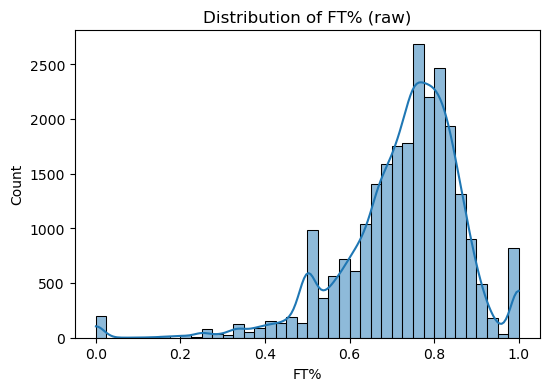

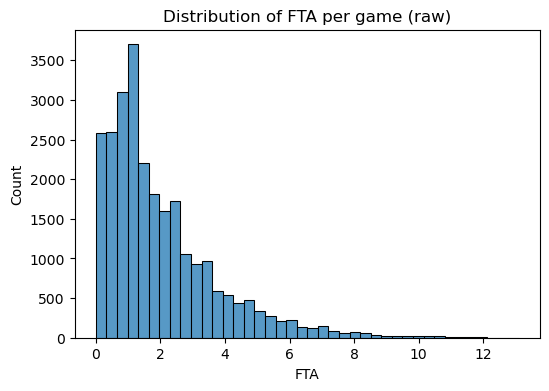

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df_raw['FT%'], bins=40, kde=True)
plt.title('Distribution of FT% (raw)')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df_raw['FTA'], bins=40, kde=False)
plt.title('Distribution of FTA per game (raw)')
plt.show()

## 7. Build Target For EDA (Only)

We create the `target` label and also build a cleaned “player-season” dataset (one row per player per season).

In [6]:
df = df_raw.copy()

# 1) Remove non-player rows
df = df[df['Player'] != 'League Average'].copy()

# 2) Keep one row per player-season
# If a player has a multi-team summary row like '2TM', keep that; otherwise keep the first row.
team_is_tm = df['Team'].astype(str).str.match(r'^\d+TM$')

rows = []
for (season, player), grp in df.groupby(['Season','Player'], sort=False):
    tm = grp[team_is_tm.loc[grp.index]]
    if len(tm) > 0:
        rows.append(tm.iloc[[0]])
    else:
        rows.append(grp.iloc[[0]])

df = pd.concat(rows, ignore_index=True)

# 3) Bring in league average FT% per season from the original raw df
league = df_raw[df_raw['Player']=='League Average'][['Season','FT%']].rename(columns={'FT%':'league_ft_pct'})
df = df.merge(league, on='Season', how='left')

# 4) Drop rows where we cannot form a target
# (Mostly rows missing FT%)
df = df.dropna(subset=['FT%','league_ft_pct']).copy()

# 5) Build target
df['target'] = (df['FT%'] >= df['league_ft_pct']).astype(int)

print('Cleaned player-season shape:', df.shape)
df['target'].value_counts(normalize=True)

Cleaned player-season shape: (20585, 34)


target
0    0.521691
1    0.478309
Name: proportion, dtype: float64

## 8. Relationships With Target (Very Important)

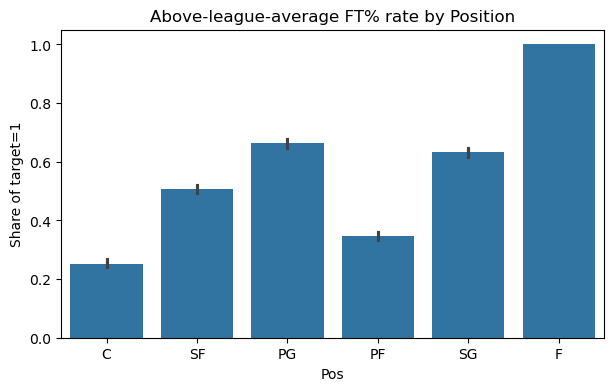

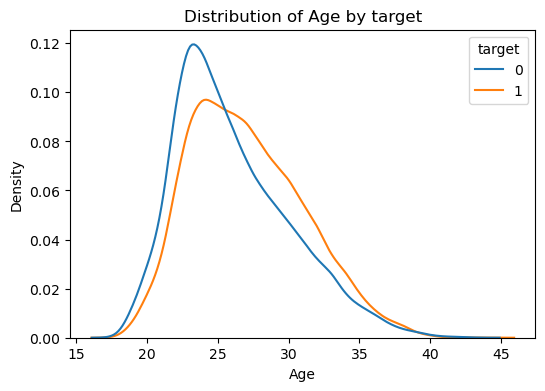

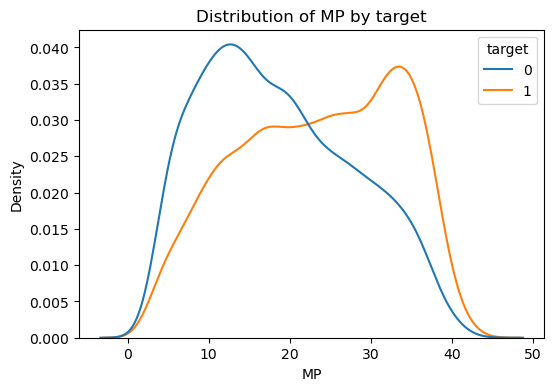

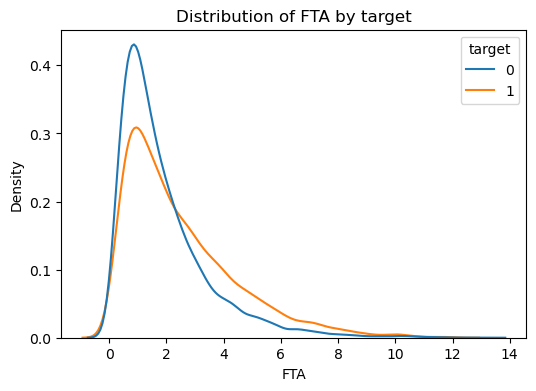

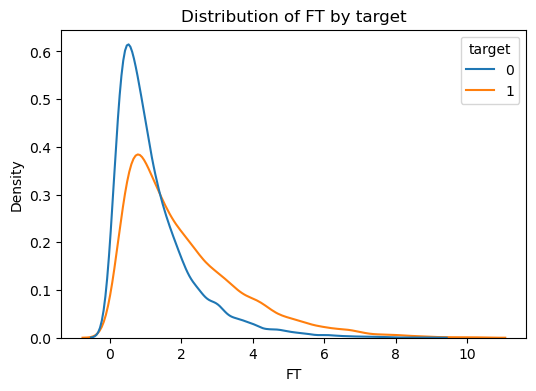

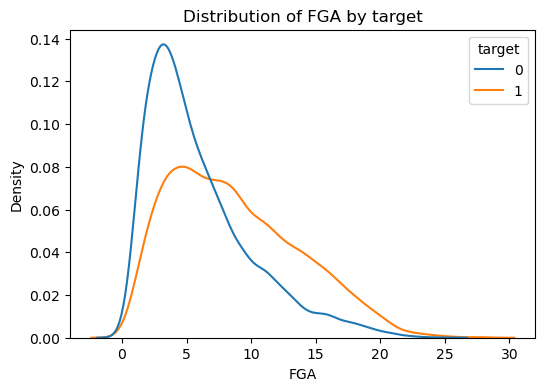

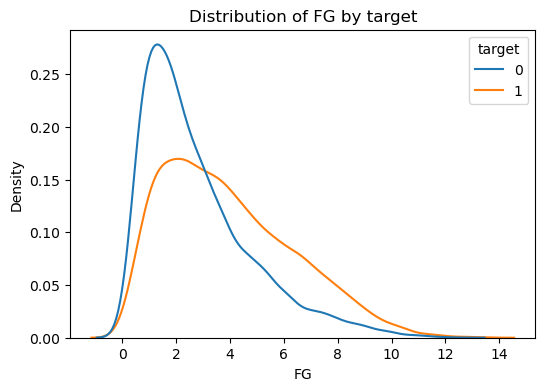

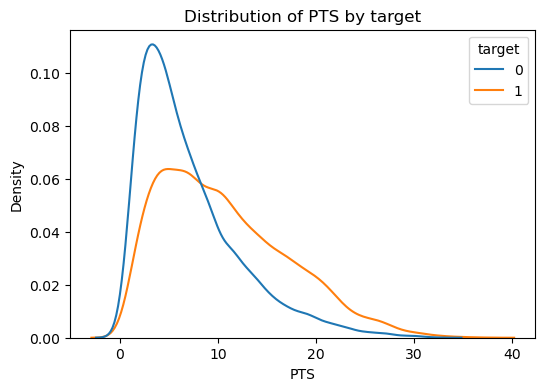

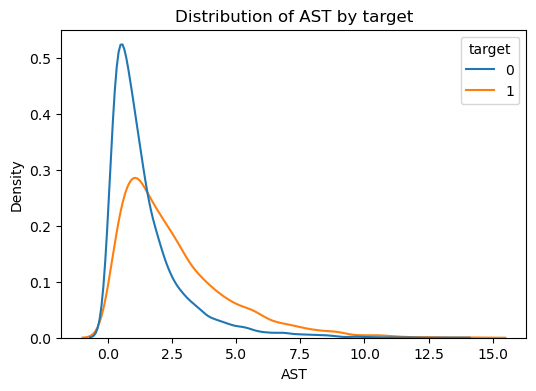

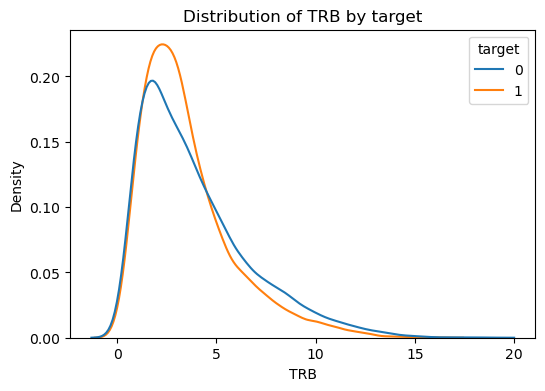

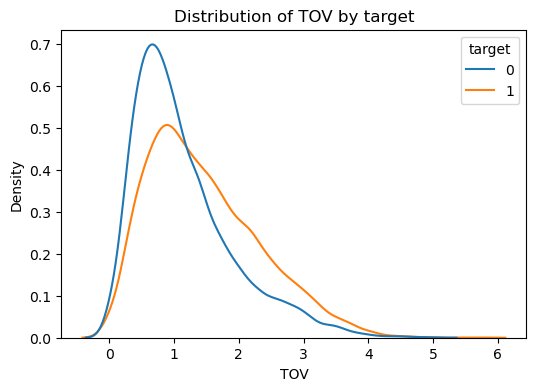

In [7]:
# Categorical: Position
plt.figure(figsize=(7,4))
sns.barplot(data=df, x='Pos', y='target', estimator=np.mean)
plt.title('Above-league-average FT% rate by Position')
plt.ylabel('Share of target=1')
plt.show()

# Numerical: compare distributions for target=0 vs target=1
num_cols = ['Age','MP','FTA','FT','FGA','FG','PTS','AST','TRB','TOV']
for c in num_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=c, hue='target', common_norm=False)
    plt.title(f'Distribution of {c} by target')
    plt.show()

## 9. Correlation Heatmap (Numeric Features)

Reminder: `FT%` is used to create the target, so it will appear strongly correlated. In the actual modeling step we will **drop `FT%` from features** to avoid leakage.

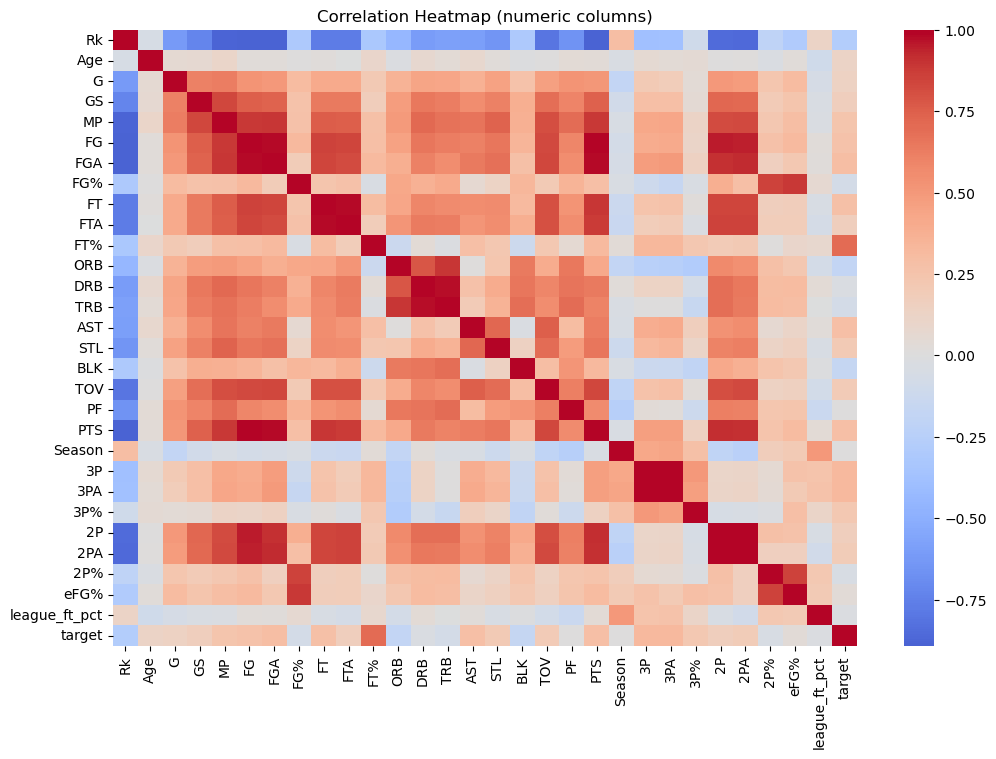

In [8]:
num_df = df.select_dtypes(include='number').copy()

plt.figure(figsize=(12,8))
corr = num_df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric columns)')
plt.show()

## 10. Quick EDA Summary (Plain Language)

Typical signals you might expect to matter for free throw ability:
- `Age` (experience)
- `Pos` (role differences)
- Shooting/usage indicators like `FGA`, `PTS`, `MP`
- Contact/physical play proxies like `FTA` and `PF`

But we must be careful: some columns directly define or leak the target (`FT%`). We will remove those from features in modeling.